In [2]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import joblib
import plotly.express as px
import math

from matplotlib.pyplot import xlabel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve

import seaborn as sns

# Loading Data

In [3]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [4]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [5]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

In [6]:
# Fit the label encoder to the classes (industry names)
le = LabelEncoder()
le.fit(df_train["industry"])
df_train["industry_encoded"] = le.transform(df_train["industry"])


In [7]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [8]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [9]:
le = LabelEncoder()
le.fit(df_val["industry"])
df_val["industry_encoded"] = le.transform(df_val["industry"])

In [10]:
le.classes_

array(['Automobiles & Components', 'Banks', 'Capital Goods',
       'Commercial & Professional Services',
       'Consumer Discretionary Distribution & Retail',
       'Consumer Durables & Apparel', 'Consumer Services',
       'Consumer Staples Distribution & Retail', 'Energy',
       'Equity Real Estate Investment Trusts (REITs)',
       'Financial Services', 'Food, Beverage & Tobacco',
       'Health Care Equipment & Services',
       'Household & Personal Products', 'Insurance', 'Materials',
       'Media & Entertainment',
       'Pharmaceuticals, Biotechnology & Life Sciences',
       'Real Estate Management & Development',
       'Semiconductors & Semiconductor Equipment', 'Software & Services',
       'Technology Hardware & Equipment', 'Telecommunication Services',
       'Transportation', 'Utilities'], dtype=object)

In [11]:
for industry, number in zip(le.classes_, range(len(le.classes_))):
    print(f"{industry} -> {number}")

Automobiles & Components -> 0
Banks -> 1
Capital Goods -> 2
Commercial & Professional Services -> 3
Consumer Discretionary Distribution & Retail -> 4
Consumer Durables & Apparel -> 5
Consumer Services -> 6
Consumer Staples Distribution & Retail -> 7
Energy -> 8
Equity Real Estate Investment Trusts (REITs) -> 9
Financial Services -> 10
Food, Beverage & Tobacco -> 11
Health Care Equipment & Services -> 12
Household & Personal Products -> 13
Insurance -> 14
Materials -> 15
Media & Entertainment -> 16
Pharmaceuticals, Biotechnology & Life Sciences -> 17
Real Estate Management & Development -> 18
Semiconductors & Semiconductor Equipment -> 19
Software & Services -> 20
Technology Hardware & Equipment -> 21
Telecommunication Services -> 22
Transportation -> 23
Utilities -> 24


In [12]:
y_train = df_train["industry_encoded"]
y_val =  df_val["industry_encoded"]

In [13]:
# Returns "True" if both arrays have the same labels.
np.array_equal(np.unique(y_train), np.unique(y_val))

True

# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

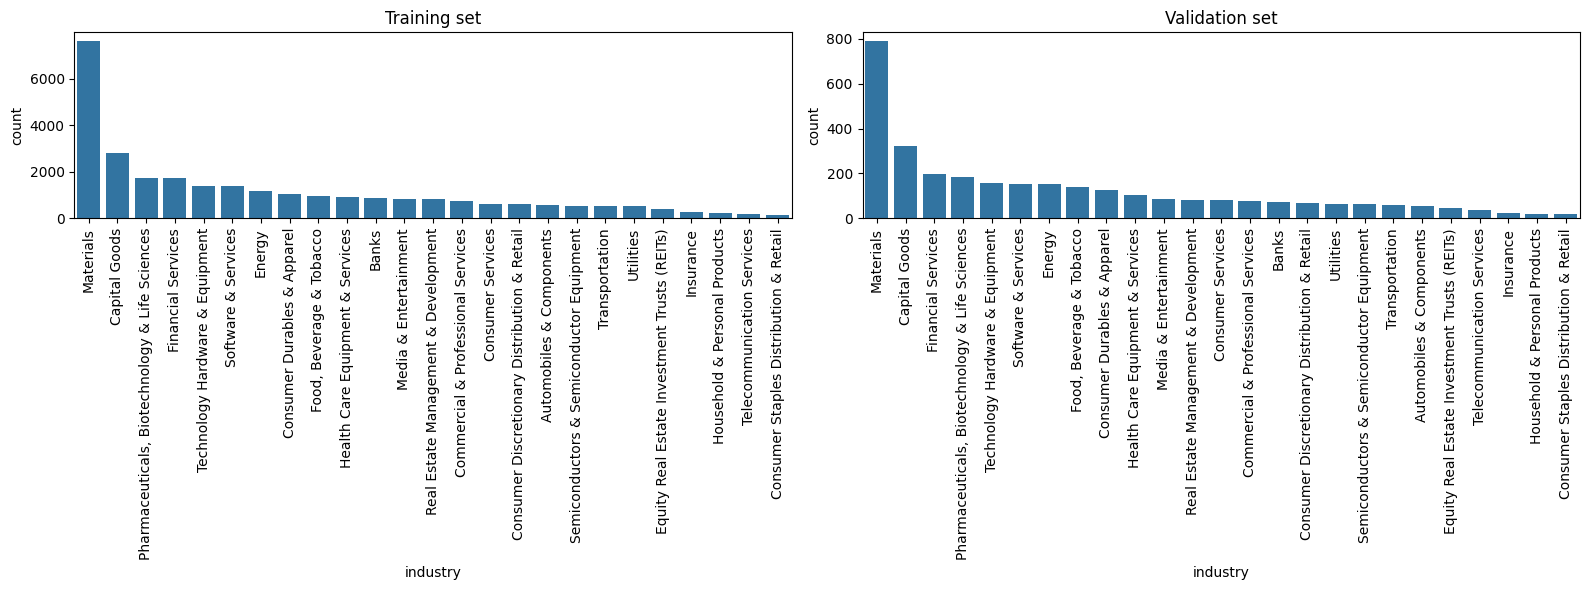

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

for ax, df, title in zip(axes, [df_train, df_val], ["Training set", "Validation set"]):
    sns.countplot(
        data=df,
        x="industry",
        order=df["industry"].value_counts().index,
        ax=ax
    )
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The industry _Materials_ is overrepresented towards all other industries. Due to this issue, a classification model will recocnise companys of the label _Materials_ better than others. Nevertheless, the distibution is more or less the same for both train and val datasets.

### PCA - Dimensionality reduction and visualization

In [15]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)



In [16]:
pca_df = pd.DataFrame({
    "PC1": X_train_pca[:, 0],
    "PC2": X_train_pca[:, 1],
    "industry_encoded": df_train["industry_encoded"],
    "industry": le.inverse_transform(df_train["industry_encoded"])
})

fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    color="industry",
    title="PCA of Training Data",
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    hover_data=["industry"]
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(
    width=800,
    height=600,
    legend_title_text="Industry Label"
)

fig.show()

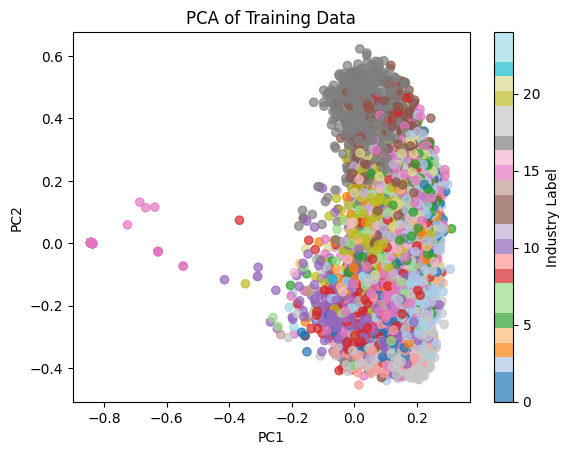

In [17]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=df_train["industry_encoded"], cmap=plt.get_cmap("tab20", len(le.classes_)), alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Training Data")
plt.colorbar(label="Industry Label")
plt.show()

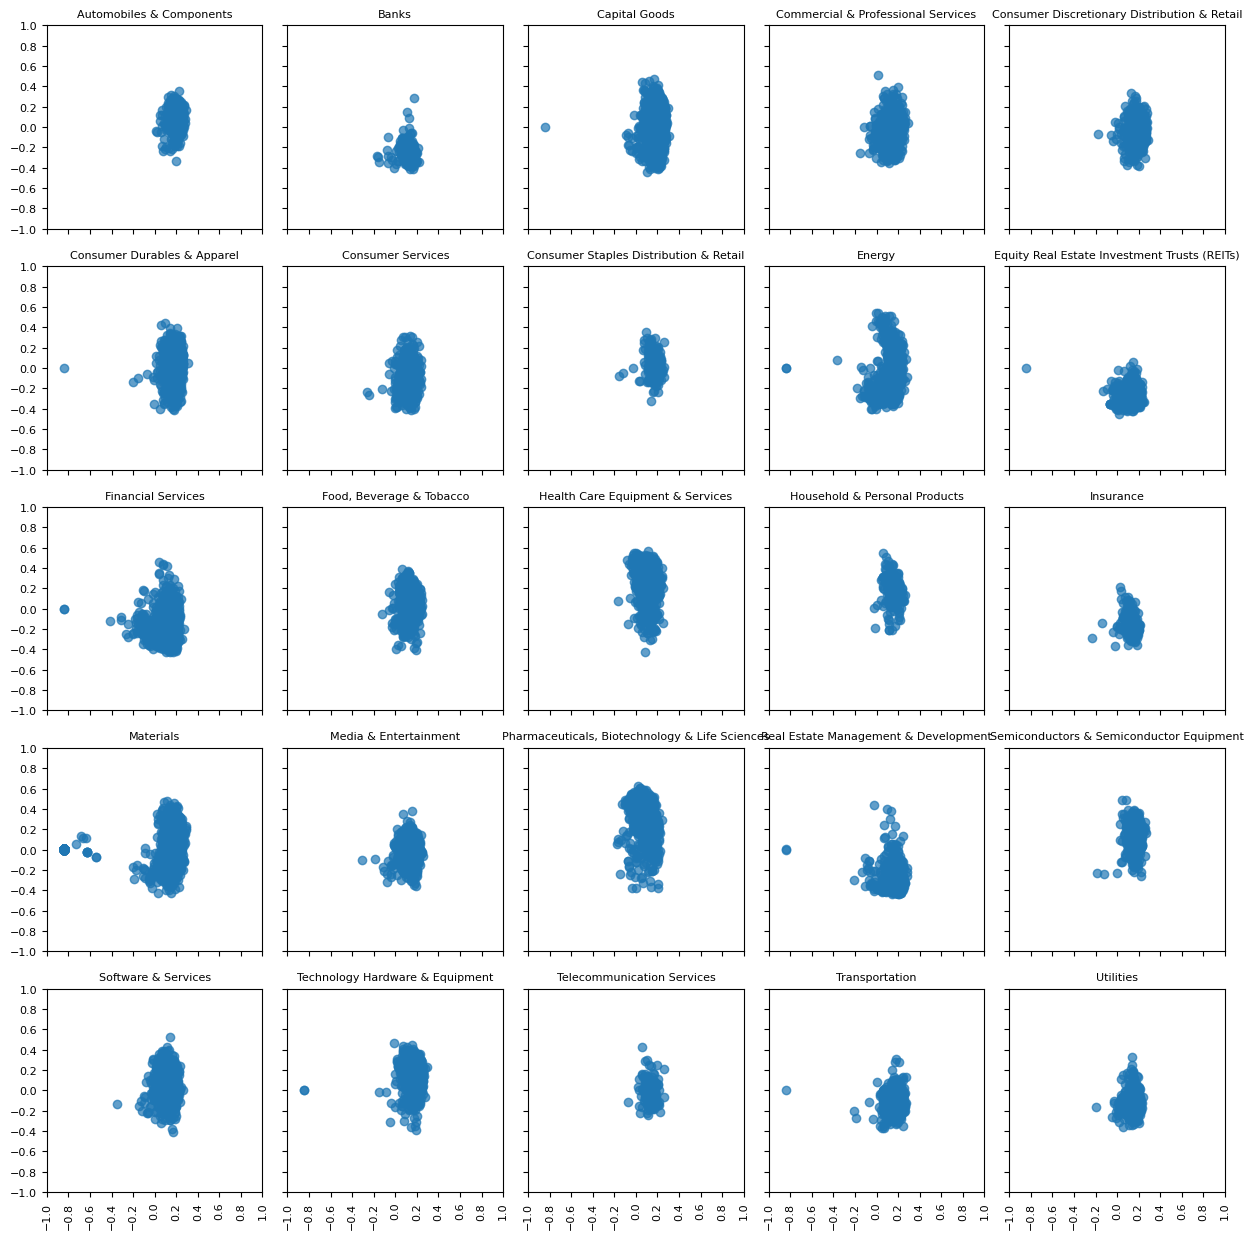

In [18]:
num_classes = len(le.classes_)  # 25

# Grid for subplots (5x5)
n_cols = 5
n_rows = int(np.ceil(num_classes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.5, n_rows*2.5), sharex=True, sharey=True)

axes = axes.flatten()  # Flatten in order to iterate more efficiently

for i, industry_label in enumerate(le.classes_):
    ax = axes[i]
    # All points of this industry
    idx = df_train["industry"] == industry_label
    ax.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], alpha=0.7)
    ax.set_title(industry_label, fontsize=8)
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_yticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
    ax.set_xticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

plt.tight_layout()
plt.show()


# Fitting and comparing Classifier Models

## Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots!

## Logistic Regression

In [19]:
# Logistic Regression Classification
clf = LogisticRegression(random_state=42).fit(X_train, y_train)
y_pred = clf.predict(X_val)

In [20]:
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred, average="weighted"):.4f}")

Accuracy: 0.7720
F1 Score (weighted): 0.7663


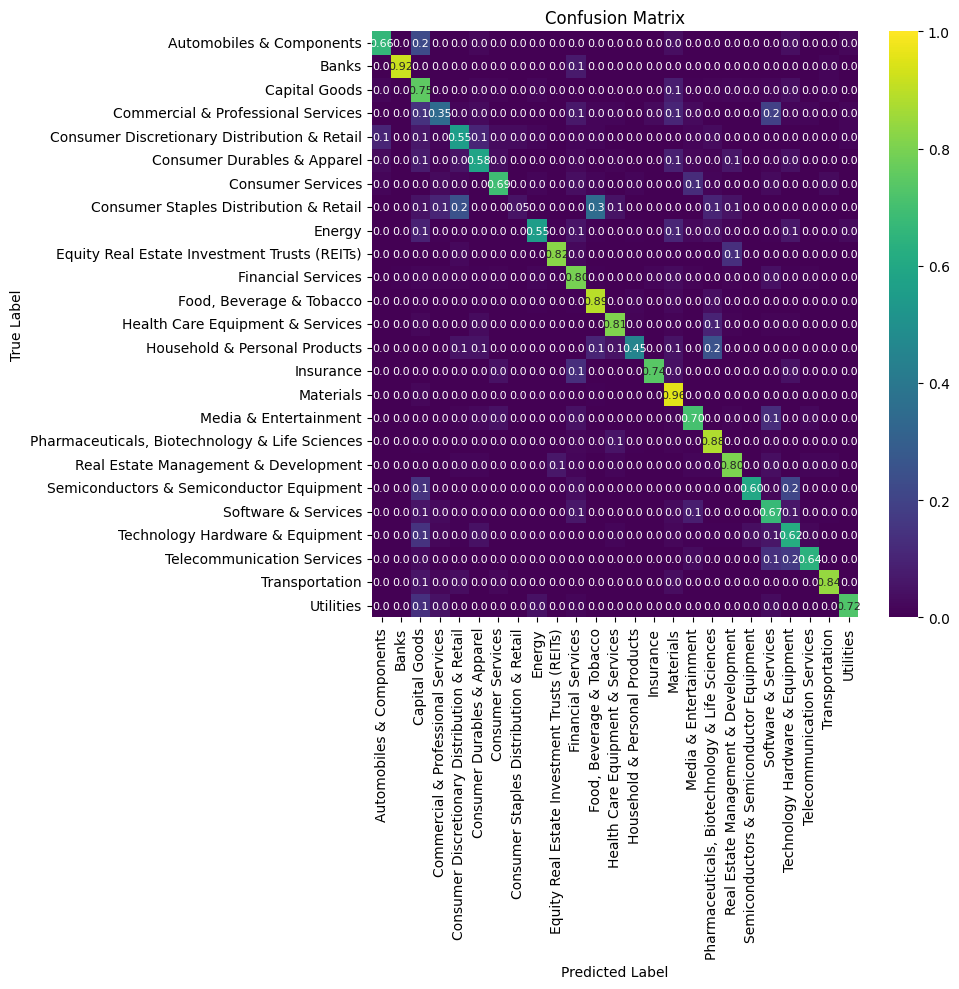

In [21]:
cm = confusion_matrix(y_val, y_pred, normalize="true")

# Annot-Array (only values on the diagonal will be .2f)
annot = np.empty_like(cm, dtype=object)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i == j:
            annot[i, j] = f"{cm[i, j]:.2f}"  # diagonal: 2 decimals
        else:
            annot[i, j] = f"{cm[i, j]:.1f}"  # rest: 1 decimal

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=annot,                    # ->annot array
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt="",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## kNN Classifier

In [22]:
neigh = KNeighborsClassifier(n_neighbors=15, weights="distance", p=1, metric="euclidean")
neigh.fit(X_train, y_train)
y_pred = neigh.predict(X_val)
neigh.fit(X_train, y_train)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "C:\Users\leoni\Documents\UZH\1. Semester\Foundations of Data Science\Practical_1\FDS25-T043\venv\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\leoni\AppData\Local\Programs\Python\Python312\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap

,n_neighbors,15
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [23]:
y_pred_knn = neigh.predict(X_val)

In [24]:
print(f"Accuracy: {accuracy_score(y_val, y_pred_knn):.4f}")
print(f"F1 Score (weighted): {f1_score(y_val, y_pred_knn, average="weighted"):.4f}")

Accuracy: 0.7755
F1 Score (weighted): 0.7698


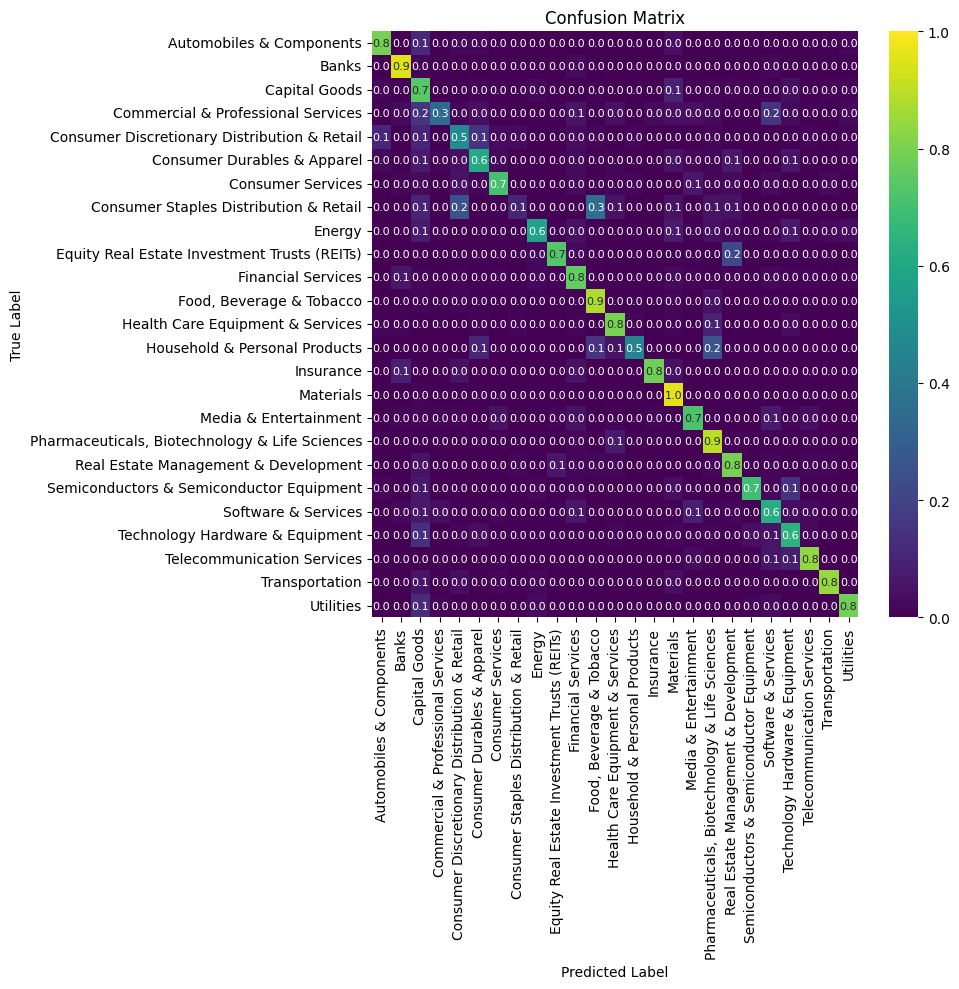

In [25]:
cm = confusion_matrix(y_val, y_pred_knn, normalize="true")

plt.figure(figsize=(10, 10))
sns.heatmap(cm,
            annot=True,
            cmap="viridis",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            vmin=0, vmax=1,
            fmt=".1f",
            annot_kws={"fontsize": 8}
            )

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [26]:
text_embeddings = pd.read_pickle("data/df_train.pkl")

In [27]:
# Import the financial data
fin_data = pd.read_pickle("data/df_financials_train.pkl")

In [28]:
print(len(text_embeddings))
print(len(fin_data))

31706
29561


In [29]:
fin_data.head()

,id,country_code,net_profit_margin,ebitda_margin,asset_turnover
0,0,CHN,0.303422,NaN,0.025426
1,1,CHN,-0.141921,-0.130371,0.266802
2,2,CHN,-1.333215,NaN,0.317023
3,3,CHN,-0.258595,NaN,0.352064
4,4,CHN,0.183619,NaN,0.963834


In [30]:
fin_data.replace([np.inf, -np.inf], np.nan, inplace=True)

In [31]:
fin_data

,id,country_code,net_profit_margin,ebitda_margin,asset_turnover
0,0,CHN,0.303422,NaN,0.025426
1,1,CHN,-0.141921,-0.130371,0.266802
2,2,CHN,-1.333215,NaN,0.317023
3,3,CHN,-0.258595,NaN,0.352064
4,4,CHN,0.183619,NaN,0.963834
...,...,...,...,...,...
38413,43791,DEU,-0.350870,-0.208024,0.058091
38415,43793,ZAF,0.079522,0.330507,0.780814
38416,43794,CAN,NaN,NaN,0.000000
38417,43795,DEU,-0.068950,NaN,2.796385


In [32]:
fin_data.drop("ebitda_margin", axis=1, inplace = True)

In [33]:
fin_data

,id,country_code,net_profit_margin,asset_turnover
0,0,CHN,0.303422,0.025426
1,1,CHN,-0.141921,0.266802
2,2,CHN,-1.333215,0.317023
3,3,CHN,-0.258595,0.352064
4,4,CHN,0.183619,0.963834
...,...,...,...,...
38413,43791,DEU,-0.350870,0.058091
38415,43793,ZAF,0.079522,0.780814
38416,43794,CAN,NaN,0.000000
38417,43795,DEU,-0.068950,2.796385


In [34]:
fin_data.dropna(inplace=True)

In [35]:
print(len(fin_data))

26125


In [36]:
# Merge the fin_data with the embeddings data
df_text_embeddings_financial = pd.merge(text_embeddings, fin_data, how="left", on="id")

In [37]:
df_text_embeddings_financial.sort_values("id")

,id,industry,business_description_embedding,country_code,net_profit_margin,asset_turnover
22620,0,Banks,"[0.04980264,-0.051249698,-0.021958234,-0.01592...",CHN,0.303422,0.025426
20728,1,Real Estate Management & Development,"[0.03318997,-0.024402514,-0.031233385,-0.01657...",CHN,-0.141921,0.266802
17137,2,"Pharmaceuticals, Biotechnology & Life Sciences","[0.042543165,-0.04768226,-0.029978378,-0.02993...",CHN,-1.333215,0.317023
11022,3,Real Estate Management & Development,"[0.003262318,0.0061992286,-0.013497011,0.03580...",CHN,-0.258595,0.352064
20790,4,Consumer Services,"[0.051957257,-0.029621216,-0.0077674626,0.0072...",CHN,0.183619,0.963834
...,...,...,...,...,...,...
15479,43791,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",DEU,-0.350870,0.058091
3304,43793,Capital Goods,"[0.011692137,-0.026472978,-0.02581276,0.007528...",ZAF,0.079522,0.780814
3243,43794,Financial Services,"[-0.0029479305,0.06150169,-0.003989088,-0.0242...",NaN,NaN,NaN
4624,43795,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",DEU,-0.068950,2.796385


In [38]:
df_text_embeddings_financial.dropna(inplace=True)

In [39]:
df_text_embeddings_financial

,id,industry,business_description_embedding,country_code,net_profit_margin,asset_turnover
0,42576,Banks,"[0.03411475,-0.03753958,0.023233214,-0.0017205...",USA,0.155503,0.033292
1,21752,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",DEU,0.023660,0.861915
2,804,Commercial & Professional Services,"[0.033574868,-0.020379327,-0.03221274,-0.01133...",CHN,0.001364,1.348739
3,31603,Insurance,"[0.020648101,0.017270269,-0.032921147,-0.01411...",IDN,0.022178,0.461366
4,11333,Capital Goods,"[-0.0006651232,0.011097765,-0.01976973,0.02299...",CHN,0.071349,0.555100
...,...,...,...,...,...,...
31703,6403,Capital Goods,"[0.022082254,-0.015513622,-0.029084805,0.02645...",CHN,0.032470,0.465017
31704,12224,Capital Goods,"[-0.031132907,-0.049892895,-0.02100823,0.03896...",CHN,0.070754,0.427210
31705,42174,Transportation,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",DEU,0.057209,0.811376
31706,754,Technology Hardware & Equipment,"[0.04300068,-0.111498445,-0.0044387826,-0.0004...",CHN,0.030016,0.577162


In [40]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

country_ohe = ohe.fit_transform(df_text_embeddings_financial[['country_code']])
country_ohe_df = pd.DataFrame(country_ohe, columns=ohe.get_feature_names_out(['country_code']), index=df_text_embeddings_financial.index)
df_text_embeddings_financial = pd.concat([df_text_embeddings_financial.drop(columns=['country_code']), country_ohe_df], axis=1)

df_text_embeddings_financial.head(3)

,id,industry,business_description_embedding,net_profit_margin,asset_turnover,country_code_ARE,country_code_ARG,country_code_AUS,country_code_AUT,country_code_AZE,...,country_code_THA,country_code_TUR,country_code_TWN,country_code_UKR,country_code_URY,country_code_USA,country_code_VGB,country_code_VNM,country_code_ZAF,country_code_ZMB
0,42576,Banks,"[0.03411475,-0.03753958,0.023233214,-0.0017205...",0.155503,0.033292,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,21752,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",0.023660,0.861915,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,804,Commercial & Professional Services,"[0.033574868,-0.020379327,-0.03221274,-0.01133...",0.001364,1.348739,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [41]:
le = LabelEncoder()
le.fit(df_text_embeddings_financial["industry"])
df_text_embeddings_financial["industry_encoded"] = le.transform(df_text_embeddings_financial["industry"])

In [42]:
df_text_embeddings_financial

,id,industry,business_description_embedding,net_profit_margin,asset_turnover,country_code_ARE,country_code_ARG,country_code_AUS,country_code_AUT,country_code_AZE,...,country_code_TUR,country_code_TWN,country_code_UKR,country_code_URY,country_code_USA,country_code_VGB,country_code_VNM,country_code_ZAF,country_code_ZMB,industry_encoded
0,42576,Banks,"[0.03411475,-0.03753958,0.023233214,-0.0017205...",0.155503,0.033292,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
1,21752,Materials,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",0.023660,0.861915,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15
2,804,Commercial & Professional Services,"[0.033574868,-0.020379327,-0.03221274,-0.01133...",0.001364,1.348739,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,31603,Insurance,"[0.020648101,0.017270269,-0.032921147,-0.01411...",0.022178,0.461366,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14
4,11333,Capital Goods,"[-0.0006651232,0.011097765,-0.01976973,0.02299...",0.071349,0.555100,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31703,6403,Capital Goods,"[0.022082254,-0.015513622,-0.029084805,0.02645...",0.032470,0.465017,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
31704,12224,Capital Goods,"[-0.031132907,-0.049892895,-0.02100823,0.03896...",0.070754,0.427210,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
31705,42174,Transportation,"[-0.025557408,0.0636078,-0.01350581,-0.0180223...",0.057209,0.811376,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23
31706,754,Technology Hardware & Equipment,"[0.04300068,-0.111498445,-0.0044387826,-0.0004...",0.030016,0.577162,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,21


In [43]:
# Remove outliers regarding financial data
financial_cols = ["asset_turnover", "net_profit_margin"]
df_text_embeddings_financial_clean = df_text_embeddings_financial.copy()

for col in financial_cols:
    lower = df_text_embeddings_financial_clean[col].quantile(0.01)
    upper = df_text_embeddings_financial_clean[col].quantile(0.99)
    df_text_embeddings_financial_clean = df_text_embeddings_financial_clean[(df_text_embeddings_financial_clean[col] >= lower) & (df_text_embeddings_financial_clean[col] <= upper)]

print(f"After 1%-Trim: {len(df_text_embeddings_financial_clean)} Rows left (of {len(df_text_embeddings_financial)})")


After 1%-Trim: 25089 Rows left (of 26127)


In [44]:
X = df_text_embeddings_financial_clean.drop(columns=['industry'])
y = df_text_embeddings_financial_clean['industry_encoded']

# Split in Train / Validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [45]:
# Embeddings in NumPy-Arrays
X_train_embed = np.vstack(X_train['business_description_embedding'].apply(ast.literal_eval))
X_val_embed   = np.vstack(X_val['business_description_embedding'].apply(ast.literal_eval))

In [46]:
# Norm the embeddings
scaler_embed = StandardScaler()
X_train_embed_scaled = scaler_embed.fit_transform(X_train_embed)
X_val_embed_scaled = scaler_embed.transform(X_val_embed)

In [47]:
# KNN-model
knn_clf = KNeighborsClassifier(
    n_neighbors=15,
    metric='cosine',  # cosine for the embeddings
    weights='distance'
)

knn_clf.fit(X_train_embed_scaled, y_train)
y_pred_knn = knn_clf.predict(X_val_embed_scaled)
print("KNN F1:", f1_score(y_val, y_pred_knn, average="macro"))

KNN F1: 0.726891698511608


In [48]:
# All columns except embedding and target
exclude_cols = ['id', 'industry', 'business_description_embedding', 'industry_encoded']
tabular_cols = [c for c in X_train.columns if c not in exclude_cols]

X_train_tab = X_train[tabular_cols].values
X_val_tab   = X_val[tabular_cols].values

scaler_tab = StandardScaler()
X_train_tab_scaled = scaler_tab.fit_transform(X_train_tab)
X_val_tab_scaled = scaler_tab.transform(X_val_tab)

# Logistic Regression
lr_clf = LogisticRegression(
    solver='saga',
    penalty='elasticnet',
    l1_ratio=0.5,
    max_iter=200,
    random_state=42,
    verbose=1
)

lr_clf.fit(X_train_tab, y_train)
y_pred_lr = lr_clf.predict(X_val_tab)
print("LogReg F1:", f1_score(y_val, y_pred_lr, average="macro"))


max_iter reached after 69 seconds
LogReg F1: 0.1197082991967503


C:\Users\leoni\Documents\UZH\1. Semester\Foundations of Data Science\Practical_1\FDS25-T043\venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished


In [49]:
proba_knn = knn_clf.predict_proba(X_val_embed_scaled)
proba_lr  = lr_clf.predict_proba(X_val_tab_scaled)

In [50]:
X_val_stack = np.hstack([proba_knn, proba_lr])

In [51]:
meta_clf = LogisticRegression(max_iter=500, random_state=42)
meta_clf.fit(np.hstack([
    knn_clf.predict_proba(X_train_embed_scaled),
    lr_clf.predict_proba(X_train_tab_scaled)
]), y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [52]:
y_pred_meta = meta_clf.predict(X_val_stack)

In [53]:
print("Stacking F1:", f1_score(y_val, y_pred_meta, average="macro"))

Stacking F1: 0.7227585084541664


In [54]:
y_pred_proba_meta = meta_clf.predict_proba(X_val_stack)

In [55]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

In [78]:
f1_scores = []
for c in range(25):
    y_true_c = (y_val == c).astype(int)
    y_pred_c = (y_pred_meta == c).astype(int)
    conf_c = y_pred_proba_meta[:, c]  # Model confidence for class c
    f1_scores.append(confidence_weighted_f1(y_true_c, y_pred_c, conf_c))

# Average score over all classes
weighted_f1 = np.mean(f1_scores)
print("Multiclass confidence-weighted F1:", weighted_f1)

Multiclass confidence-weighted F1: 0.8702254782652156


In [82]:
confidence_weighted_f1(y_true_c, y_pred_c, conf_c)

np.float64(0.8879620393372604)

In [68]:
f1_scores

[np.float64(0.8671186337957926),
 np.float64(0.9451059614234267),
 np.float64(0.8294084123684834),
 np.float64(0.7868060489387272),
 np.float64(0.8185991693423251),
 np.float64(0.861801917847532),
 np.float64(0.8879218854805979),
 np.float64(0.7628717678880627),
 np.float64(0.8933613275942253),
 np.float64(0.8985139856793536),
 np.float64(0.894539076219392),
 np.float64(0.9036599535320533),
 np.float64(0.8854255499147538),
 np.float64(0.8281809842262741),
 np.float64(0.971794388913399),
 np.float64(0.9662198607133092),
 np.float64(0.8976033865758549),
 np.float64(0.8917465528981968),
 np.float64(0.8612131783435032),
 np.float64(0.861986290070286),
 np.float64(0.8337718702072583),
 np.float64(0.7911287353193279),
 np.float64(0.847538256538394),
 np.float64(0.8813577234626028),
 np.float64(0.8879620393372604)]

In [67]:
f1_scores = []
class_weights = []

for c in range(25):
    y_true_c = (y_val == c).astype(int)
    y_pred_c = (y_pred_meta == c).astype(int)
    conf_c = y_pred_proba_meta[:, c]

    # F1 für diese Klasse
    f1_c = confidence_weighted_f1(y_true_c, y_pred_c, conf_c)
    f1_scores.append(f1_c)

    # Gewicht = Anteil dieser Klasse im Datensatz
    class_weight = np.sum(y_val == c) / len(y_val)
    class_weights.append(class_weight)

# Weighted average
weighted_f1 = np.average(f1_scores, weights=class_weights)
print("Weighted confidence-weighted F1:", weighted_f1)

Weighted confidence-weighted F1: 0.889516301277572


Text(0.5, 1.0, 'Distribution of model confidence')

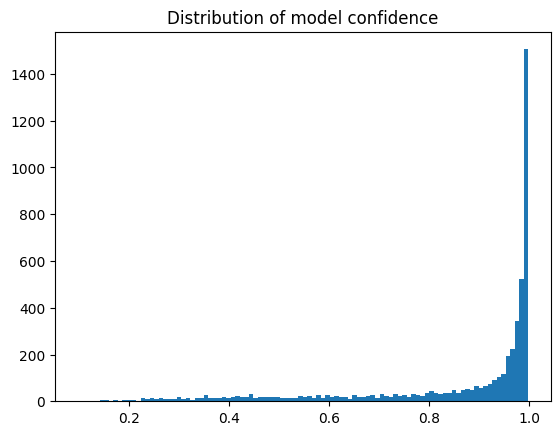

In [57]:
confidences = y_pred_proba_meta.max(axis=1)
plt.hist(confidences, bins=100)
plt.title("Distribution of model confidence")


In [58]:
correct = (y_pred_meta == y_val)
corr = np.corrcoef(confidences, correct)[0,1]
print("Correlation between confidence and accuracy:", corr)

Correlation between confidence and accuracy: 0.4578648299741944


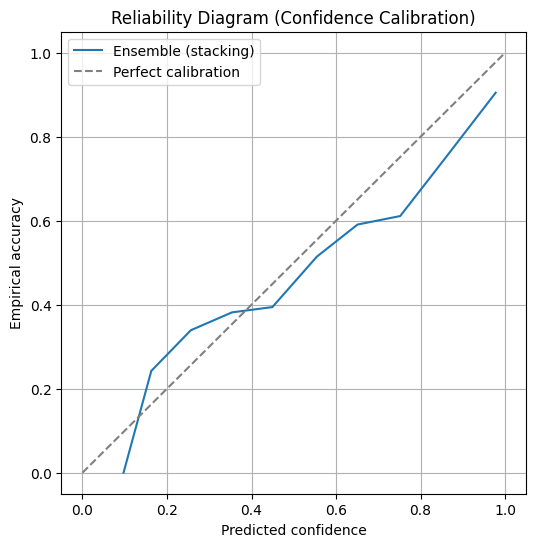

In [75]:
# We look at the maximal predicted probability for each sample
confidences = y_pred_proba_meta.max(axis=1)
accuracies = (y_pred_meta == y_val)

# 1. Bins for the confidence values (e.g 0–1 in 10 steps)
prob_true, prob_pred = calibration_curve(accuracies, confidences, n_bins=10, strategy='uniform')

# 2. Plot
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='', label='Ensemble (stacking)')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')

plt.title("Reliability Diagram (Confidence Calibration)")
plt.xlabel("Predicted confidence")
plt.ylabel("Empirical accuracy")
plt.legend()
plt.grid(True)
plt.show()


np.float64(0.8879620393372604)